# Pool-based Multilabel Active Learning - Getting Started

> **_Google Colab Note:_** If the notebook fails to run after installing the needed packages, try to restart the runtime (Ctrl + M) under Runtime -> Restart session.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](<colab_link>)

**Notebook Dependencies**

Uncomment the following cell to install all dependencies for this tutorial.

In [1]:
# !pip install scikit-activeml tqdm

The main purpose of this tutorial is to ease the implementation of our library `scikit-activeml` to new users. `scikit-activeml` is a library that executes the most important query strategies. It is built upon the well-known machine learning frame-work `scikit-learn`, which makes it user-friendly. For better understanding, we show an exemplary multilabel active learning cycle here. Let's start by importing the relevant packages from both `scikit-learn` and `scikit-activeml`.

In [1]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib as mlp
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm

from sklearn.datasets import make_multilabel_classification
from sklearn.metrics import f1_score

from skactiveml.classifier import SkorchClassifier
from skactiveml.pool import RandomSampling, CoreSet, TypiClust, MaxHerding, GreedySamplingX, ProbCover
from skactiveml.utils import MISSING_LABEL, call_func

from skorch.callbacks import LRScheduler
from torch import nn
from torch.optim.lr_scheduler import CosineAnnealingLR

import warnings

mlp.rcParams["figure.facecolor"] = "white"
warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"


## Data Set Generation
Using `make_multilabel_classification` from `scikit-learn` we generate a data set of `n_samples=1000` data points with `num_classes=5` classes where the average label density is `n_labels=3`
This method also returns the true labels of each data point. In practice, however, we do not know these labels unless we ask an oracle. The labels are stored in `Y_true`, which acts as an oracle.

Multilabel compare to multiclass classification has a one-hot-encoded vector as its target `Y`, because classes can co-exist, such that one sample can be identified by more than one class.

In [2]:
n_features = 3
n_classes = 5
X, Y_true = make_multilabel_classification(
    n_samples=1000,
    n_features=n_features,
    n_classes=n_classes,
    n_labels=3,
    random_state=1
)

## Classification

In [3]:
def topk_accuracy(preds, targets, topk=1):
    """
    Calculates the top-k accuracy.

    Parameters
    ----------
    preds : np.ndarray
        Prediction probabilities with shape (N, C).
    targets : np.ndarray
        One-hot encoded ground truth labels with shape (N, C).
    topk : int
        Number of top predictions to consider.

    Returns
    -------
    accuracy : float
        The Top-K accuracy.
    """
    # Get the indices of the top-k predictions
    topk_pred_indices = np.argsort(-preds, axis=1)[:, :topk]

    # Convert one-hot encoded targets to indices for positive cases
    correct_positive = np.any(targets[np.arange(targets.shape[0])[:, None], topk_pred_indices], axis=1)

    # Combine correct predictions
    correct = correct_positive.sum()

    # Determine total number of samples to consider
    total = len(targets)

    # Compute accuracy
    accuracy = correct / total if total > 0 else 0.0

    return accuracy

In [4]:
# parameter setup
seed = 42
n_cycles = 10
batch_size = 30
classes = [[0, 1]] * 5

In [5]:
strategies = {
    "Random": RandomSampling(random_state=seed),
    "CoreSet": CoreSet(random_state=seed),
    "TypiClust": TypiClust(random_state=seed),
    "MaxHerding": MaxHerding(random_state=seed),
    "ProbCover": ProbCover(n_classes=n_classes, random_state=seed),
    "GreedySamplingX": GreedySamplingX(random_state=seed),
}

### Evaluate Sampling Strategies

In [6]:
history_t1 = {name: [] for name in strategies.keys()}
history_f1 = {name: [] for name in strategies.keys()}

for name, qs in strategies.items():
    torch.random.manual_seed(seed)
    np.random.seed(seed)

    # Build your `torch` module for classification, which outputs:
    # - classification logits,
    # - learned sample embeddings.
    class ClassificationModule(nn.Module):
        def __init__(self, n_features, n_classes, n_hidden_units):
            super().__init__()
            self.linear_1 = nn.Linear(n_features, n_hidden_units)
            self.linear_2 = nn.Linear(n_hidden_units, n_classes)
            self.activation = nn.ReLU()

        def forward(self, x):
            x_embed = self.linear_1(x)
            logits = self.linear_2(self.activation(x_embed))
            return logits, x_embed


    # Wrap your torch module via a `skactiveml` wrapper, which requires the
    # definition of training parameters.
    clf = SkorchClassifier(
        module=ClassificationModule,
        sample_dtype=np.float32,
        forward_outputs={"proba": (0, nn.Sigmoid()), "emb": (1, None)},
        neural_net_param_dict={
            # Module-related parameters.
            "module__n_features": n_features,
            "module__n_hidden_units": 128,
            "module__n_classes": len(classes),
            # Optimizer-related parameters.
            "max_epochs": 100,
            "batch_size": 16,
            "lr": 0.01,
            "optimizer": torch.optim.RAdam,
            "callbacks": [
                ("lr_scheduler", LRScheduler(policy=CosineAnnealingLR, T_max=100))
            ],
            # General parameters.
            "verbose": 0,
            "device": device,
            "train_split": False,
            "iterator_train__shuffle": True,
        },
        classes=classes,
        missing_label=MISSING_LABEL,
        random_state=seed,
    ).initialize()

    Y = np.full(shape=Y_true.shape, fill_value=MISSING_LABEL)
    clf.fit(X, Y)
    history_t1[name].append(topk_accuracy(clf.predict(X), Y_true))
    history_f1[name].append(f1_score(clf.predict(X), Y_true, average="macro"))
    for c in tqdm(range(n_cycles), desc=name):
        query_idx = call_func(qs.query, X=X, y=Y, batch_size=batch_size, clf=clf, fit_clf=False)

        Y[query_idx] = Y_true[query_idx]
        clf.fit(X, Y)
        pred = clf.predict_proba(X)
        history_t1[name].append(topk_accuracy(clf.predict(X), Y_true))
        history_f1[name].append(f1_score(clf.predict(X), Y_true, average="macro"))


Random:   0%|          | 0/10 [00:00<?, ?it/s]

CoreSet:   0%|          | 0/10 [00:00<?, ?it/s]

TypiClust:   0%|          | 0/10 [00:00<?, ?it/s]

MaxHerding:   0%|          | 0/10 [00:00<?, ?it/s]

ProbCover:   0%|          | 0/10 [00:00<?, ?it/s]

GreedySamplingX:   0%|          | 0/10 [00:00<?, ?it/s]

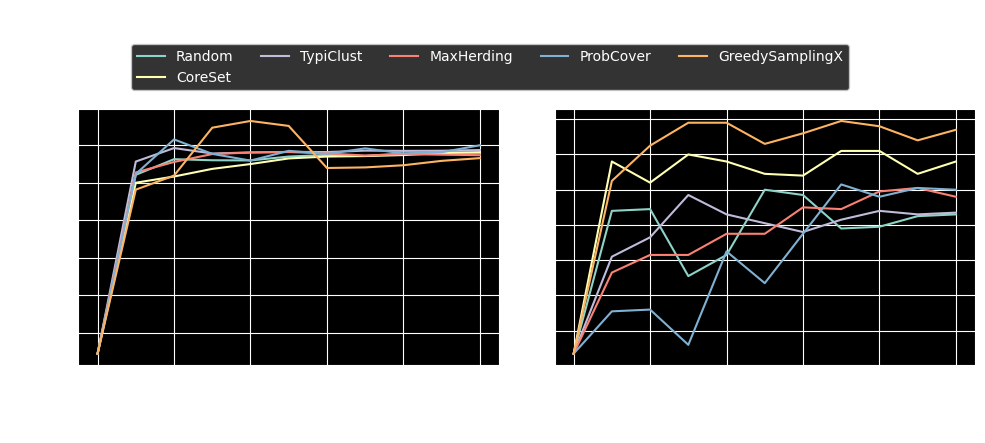

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, tight_layout=True)
histories = {"F1-macro": history_f1, "T1": history_t1}
for ax, (metric, history) in zip(axes, histories.items()):
    for name, hist in history.items():
        ax.plot(range(0, n_cycles + 1), hist, label=name)
    ax.set_title(metric)
    ax.grid(True)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(0.5, 1), ncol=5, frameon=True)
fig.suptitle(f"Sample Dataset with batch size of {batch_size}", fontsize=16, y=1.07)
fig.supxlabel("Cycle")
fig.supylabel("Performance")
plt.show()